# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

### Imports & Setup

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

### Base statistics (numerical)

In [5]:

print("=== Shape ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n=== Numerical Columns ===")
display(df.describe())

print("\n=== Categorical Columns ===")
df.describe(include=['object', 'str'])


=== Shape ===
Rows: 18,442 | Columns: 9

=== Numerical Columns ===


,Clothing ID,Age,Positive Feedback Count,Recommended IND
count,18442.000000,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484,0.816235
std,141.571783,12.246264,5.942220,0.387303
min,2.000000,18.000000,0.000000,0.000000
25%,863.000000,34.000000,0.000000,1.000000
50%,952.000000,41.000000,1.000000,1.000000
75%,1078.000000,52.000000,3.000000,1.000000
max,1205.000000,99.000000,122.000000,1.000000



=== Categorical Columns ===


,Title,Review Text,Division Name,Department Name,Class Name
count,18442,18442,18442,18442,18442
unique,13142,18439,2,6,14
top,Love it!,I purchased this and another eva franco dress ...,General,Tops,Dresses
freq,129,2,11664,8713,5371


### Correlation matrix (numerical Features)

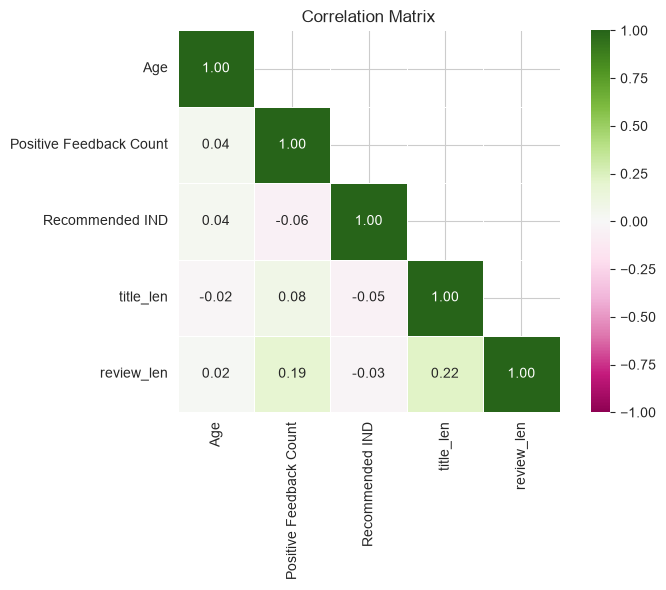

In [6]:
# Temporarily create text length columns
df['title_len'] = df['Title'].astype(str).apply(len)
df['review_len'] = df['Review Text'].astype(str).apply(len)

numeric_cols = ['Age', 'Positive Feedback Count', 'Recommended IND',
                'title_len', 'review_len']

corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='PiYG', center=0,
    square=True, linewidths=0.5, mask=mask,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Cleanup
df.drop(columns=['title_len', 'review_len'], inplace=True)


### Recommendation distribution

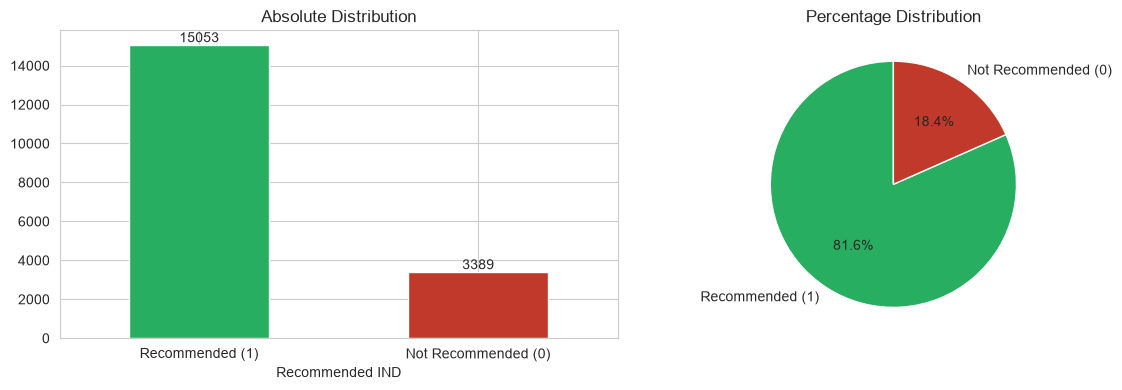

Class Balance Ratio: 81.62% recommended


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Farb- und Label-Map
color_map = {0: '#c0392b', 1: '#27ae60'}
label_map = {0: 'Not Recommended (0)', 1: 'Recommended (1)'}

# Absolute Werte
counts = df['Recommended IND'].value_counts().sort_index(ascending=False)
colors = [color_map[idx] for idx in counts.index]

counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Absolute Distribution')
axes[0].set_xticklabels([label_map[idx] for idx in counts.index], rotation=0)
axes[0].bar_label(axes[0].containers[0])

# Prozentual (direkt über matplotlib)
counts_norm = df['Recommended IND'].value_counts(normalize=True).sort_index(ascending=False)
colors_pie = [color_map[idx] for idx in counts_norm.index]
labels_pie = [label_map[idx] for idx in counts_norm.index]

axes[1].pie(
    counts_norm.values,
    labels=labels_pie,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Percentage Distribution')

plt.tight_layout()
plt.show()

print(f"Class Balance Ratio: {df['Recommended IND'].mean():.2%} recommended")

### Categorial Features (Division, Department, Class)

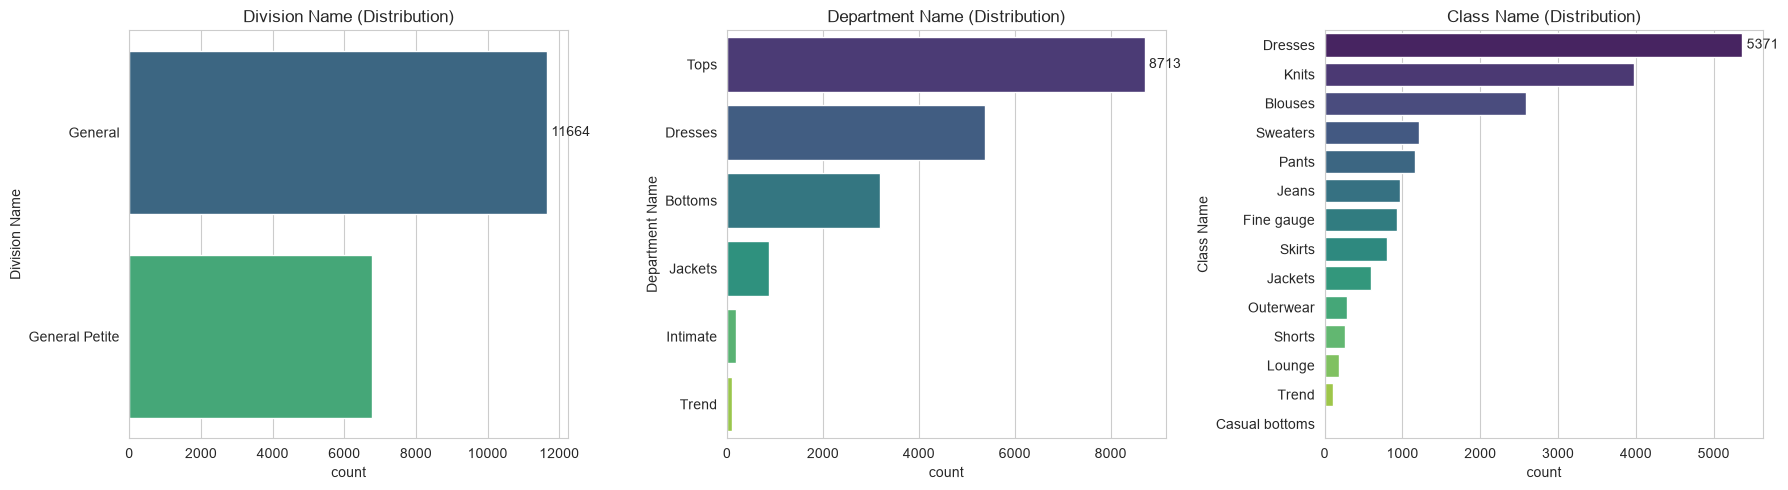

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Division Name', 'Department Name', 'Class Name']):
    order = df[col].value_counts().index
    sns.countplot(
        data=df, y=col, order=order, ax=axes[i],
        hue=col, hue_order=order, palette='viridis', legend=False
    )
    axes[i].set_title(f'{col} (Distribution)')
    axes[i].bar_label(axes[i].containers[0], padding=3)

plt.tight_layout()
plt.show()

### Recommendation per category

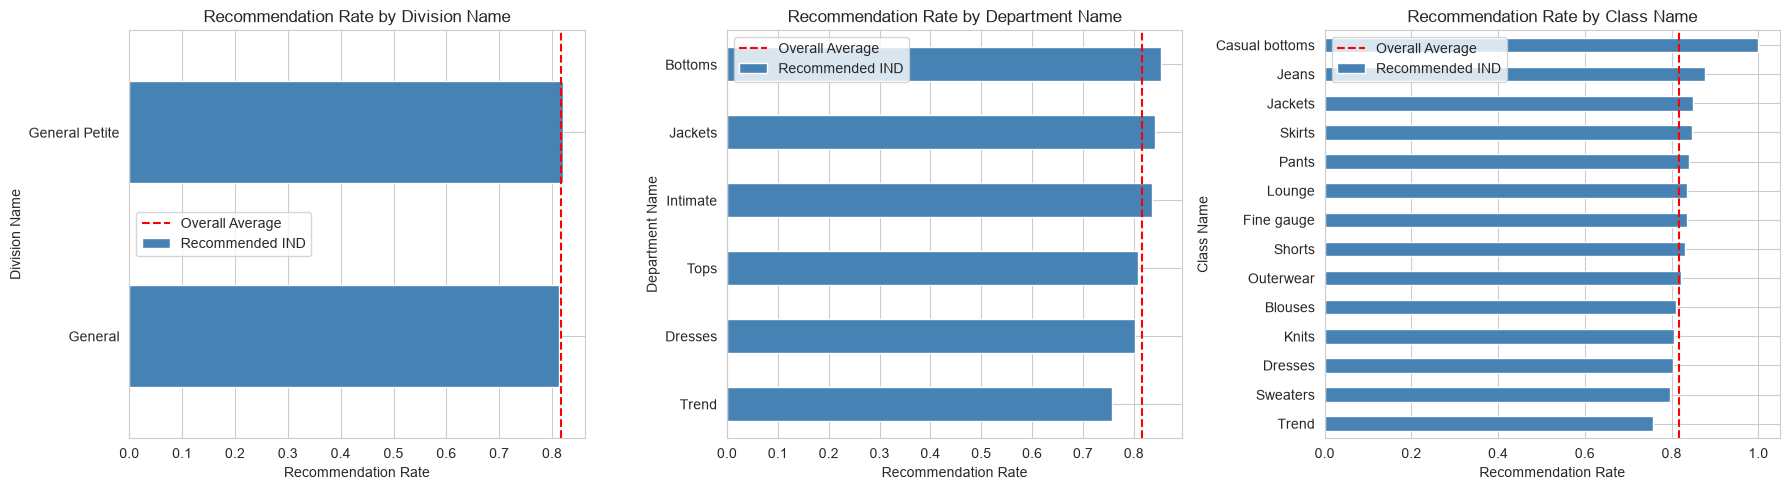

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Division Name', 'Department Name', 'Class Name']):
    rec_rate = df.groupby(col)['Recommended IND'].mean().sort_values(ascending=True)
    rec_rate.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Recommendation Rate by {col}')
    axes[i].set_xlabel('Recommendation Rate')
    axes[i].axvline(df['Recommended IND'].mean(), color='red', linestyle='--', label='Overall Average')
    axes[i].legend()

plt.tight_layout()
plt.show()

### Age distribution

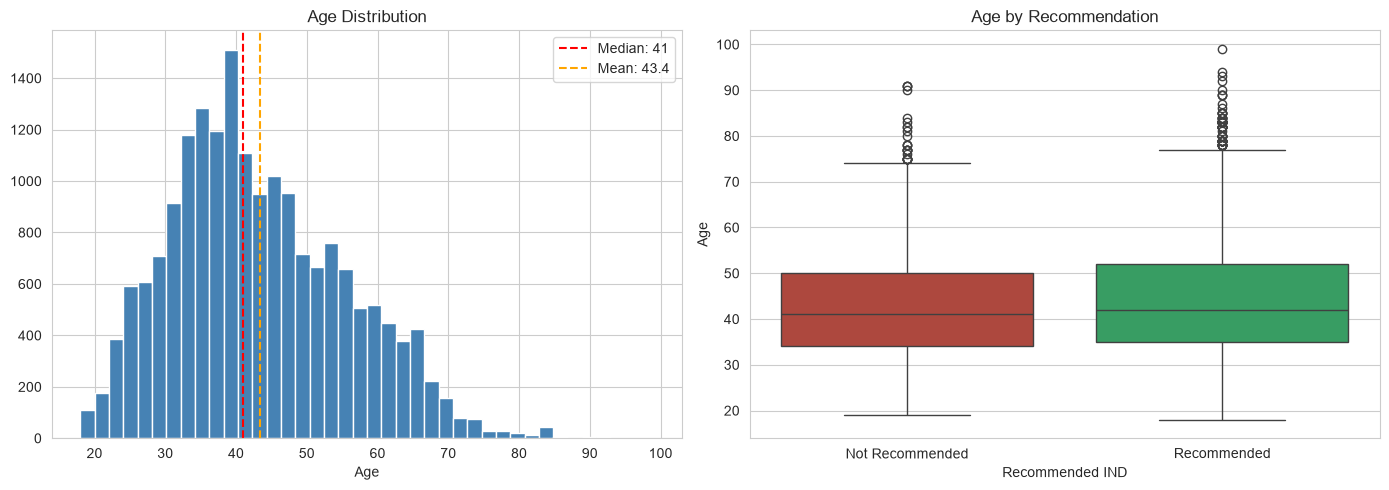

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm
df['Age'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', label=f"Median: {df['Age'].median():.0f}")
axes[0].axvline(df['Age'].mean(), color='orange', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot by Target (hue statt palette, feste Ticks)
sns.boxplot(
    data=df, x='Recommended IND', y='Age', ax=axes[1],
    hue='Recommended IND', palette={0: '#c0392b', 1: '#27ae60'}, legend=False
)
axes[1].set_title('Age by Recommendation')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Recommended', 'Recommended'])

plt.tight_layout()
plt.show()

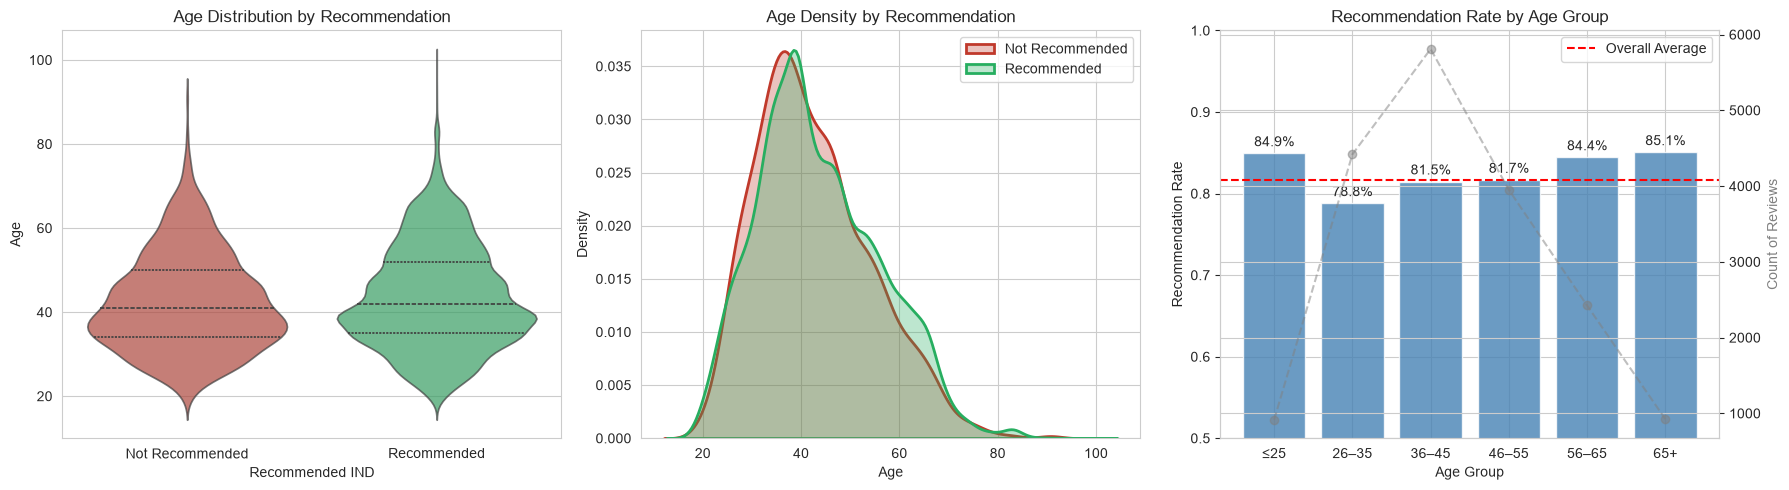

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Violin + Strip Plot
sns.violinplot(
    data=df, x='Recommended IND', y='Age', ax=axes[0],
    hue='Recommended IND', palette={0: '#c0392b', 1: '#27ae60'},
    legend=False, inner='quartile', alpha=0.7
)
axes[0].set_title('Age Distribution by Recommendation')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Recommended', 'Recommended'])

# 2) KDE Overlay
for label, color, name in [(0, '#c0392b', 'Not Recommended'), (1, '#27ae60', 'Recommended')]:
    sns.kdeplot(
        df[df['Recommended IND'] == label]['Age'],
        ax=axes[1], color=color, fill=True, alpha=0.3, label=name, linewidth=2
    )
axes[1].set_title('Age Density by Recommendation')
axes[1].set_xlabel('Age')
axes[1].legend()

# 3) Recommendation Rate by Age Group
df['age_group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['≤25', '26–35', '36–45', '46–55', '56–65', '65+'])

age_stats = df.groupby('age_group', observed=True).agg(
    rec_rate=('Recommended IND', 'mean'),
    count=('Recommended IND', 'size')
).reset_index()

bar = axes[2].bar(age_stats['age_group'], age_stats['rec_rate'], color='steelblue', alpha=0.8)
axes[2].bar_label(bar, fmt='%.1f%%', label_type='edge', padding=3,
                   labels=[f"{v:.1%}" for v in age_stats['rec_rate']])
axes[2].axhline(df['Recommended IND'].mean(), color='red', linestyle='--', label='Overall Average')
axes[2].set_title('Recommendation Rate by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Recommendation Rate')
axes[2].set_ylim(0.5, 1.0)
axes[2].legend()

# Count Reviews as secondary info
ax2 = axes[2].twinx()
ax2.plot(age_stats['age_group'], age_stats['count'], color='gray', marker='o', linestyle='--', alpha=0.5)
ax2.set_ylabel('Count of Reviews', color='gray')

plt.tight_layout()
plt.show()

# Cleanup
df.drop(columns=['age_group'], inplace=True, errors='ignore')


### Positive Feedback Count

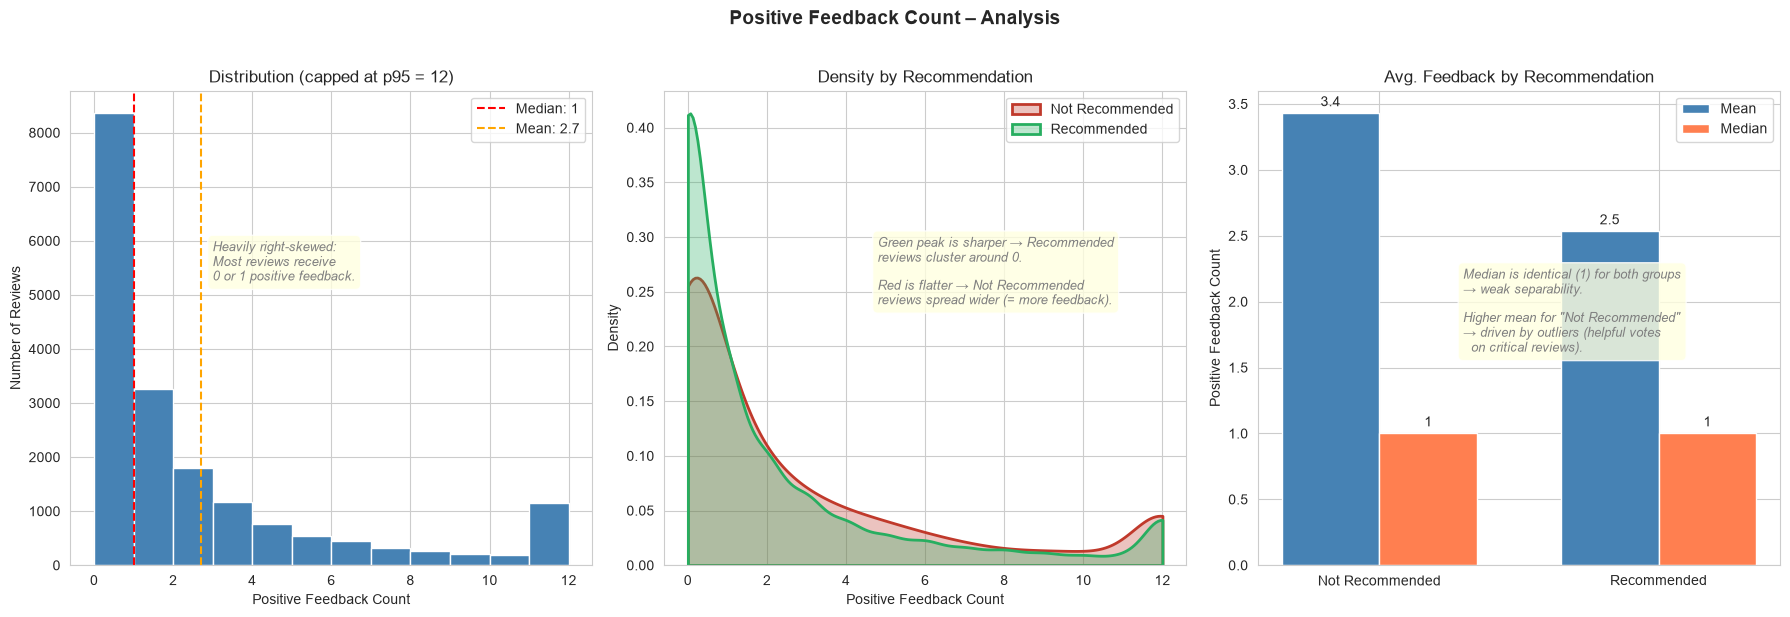

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Positive Feedback Count – Analysis', fontsize=14, fontweight='bold', y=1.02)

# --- 1) Histogram (capped at p95) ---
cap = int(df['Positive Feedback Count'].quantile(0.95))
data_capped = df['Positive Feedback Count'].clip(upper=cap)

data_capped.hist(bins=cap, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['Positive Feedback Count'].median(), color='red', linestyle='--',
                label=f"Median: {df['Positive Feedback Count'].median():.0f}")
axes[0].axvline(df['Positive Feedback Count'].mean(), color='orange', linestyle='--',
                label=f"Mean: {df['Positive Feedback Count'].mean():.1f}")
axes[0].set_title(f'Distribution (capped at p95 = {cap})')
axes[0].set_xlabel('Positive Feedback Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Annotation
axes[0].annotate(
    'Heavily right-skewed:\nMost reviews receive\n0 or 1 positive feedback.',
    xy=(3, axes[0].get_ylim()[1] * 0.6),
    fontsize=9, fontstyle='italic', color='gray',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.8)
)

# --- 2) KDE  ---
for label, color, name in [(0, '#c0392b', 'Not Recommended'), (1, '#27ae60', 'Recommended')]:
    sns.kdeplot(
        df[df['Recommended IND'] == label]['Positive Feedback Count'].clip(upper=cap),
        ax=axes[1], color=color, fill=True, alpha=0.3, label=name, linewidth=2,
        clip=(0, cap)  # prevents negative x-axis artifact
    )
axes[1].set_title('Density by Recommendation')
axes[1].set_xlabel('Positive Feedback Count')
axes[1].set_ylabel('Density')
axes[1].legend()

# Annotation
axes[1].annotate(
    'Green peak is sharper → Recommended\n'
    'reviews cluster around 0.\n\n'
    'Red is flatter → Not Recommended\n'
    'reviews spread wider (= more feedback).',
    xy=(cap * 0.4, axes[1].get_ylim()[1] * 0.55),
    fontsize=9, fontstyle='italic', color='gray',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.8)
)

# --- 3) Grouped Bar (Mean vs Median) ---
stats = df.groupby('Recommended IND')['Positive Feedback Count'].agg(['mean', 'median'])

x = np.arange(2)
width = 0.35
bar_mean = axes[2].bar(x - width/2, stats['mean'], width, color='steelblue', label='Mean')
bar_med = axes[2].bar(x + width/2, stats['median'], width, color='coral', label='Median')
axes[2].bar_label(bar_mean, fmt='%.1f', padding=3)
axes[2].bar_label(bar_med, fmt='%.0f', padding=3)
axes[2].set_title('Avg. Feedback by Recommendation')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Not Recommended', 'Recommended'])
axes[2].set_ylabel('Positive Feedback Count')
axes[2].legend()

# Annotation
axes[2].annotate(
    'Median is identical (1) for both groups\n'
    '→ weak separability.\n\n'
    'Higher mean for "Not Recommended"\n'
    '→ driven by outliers (helpful votes\n'
    '  on critical reviews).',
    xy=(0.3, axes[2].get_ylim()[1] * 0.45),
    fontsize=9, fontstyle='italic', color='gray',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.show()

In [13]:
# Summary print
print("=" * 60)
print("KEY FINDINGS: Positive Feedback Count")
print("=" * 60)
print(f"  Median:          {df['Positive Feedback Count'].median():.0f}")
print(f"  Mean:            {df['Positive Feedback Count'].mean():.1f}")
print(f"  Max:             {df['Positive Feedback Count'].max()}")
print(f"  95th Percentile: {df['Positive Feedback Count'].quantile(0.95):.0f}")
print(f"  Zero-Feedback:   {(df['Positive Feedback Count'] == 0).mean():.1%} of all reviews")
print("-" * 60)
print("  → Consider log1p transform or binary feature (has_feedback)")
print("  → Weak predictor on its own due to identical medians")
print("=" * 60)

KEY FINDINGS: Positive Feedback Count
  Median:          1
  Mean:            2.7
  Max:             122
  95th Percentile: 12
  Zero-Feedback:   45.3% of all reviews
------------------------------------------------------------
  → Consider log1p transform or binary feature (has_feedback)
  → Weak predictor on its own due to identical medians


### Text length analysis (Title & Review Text)

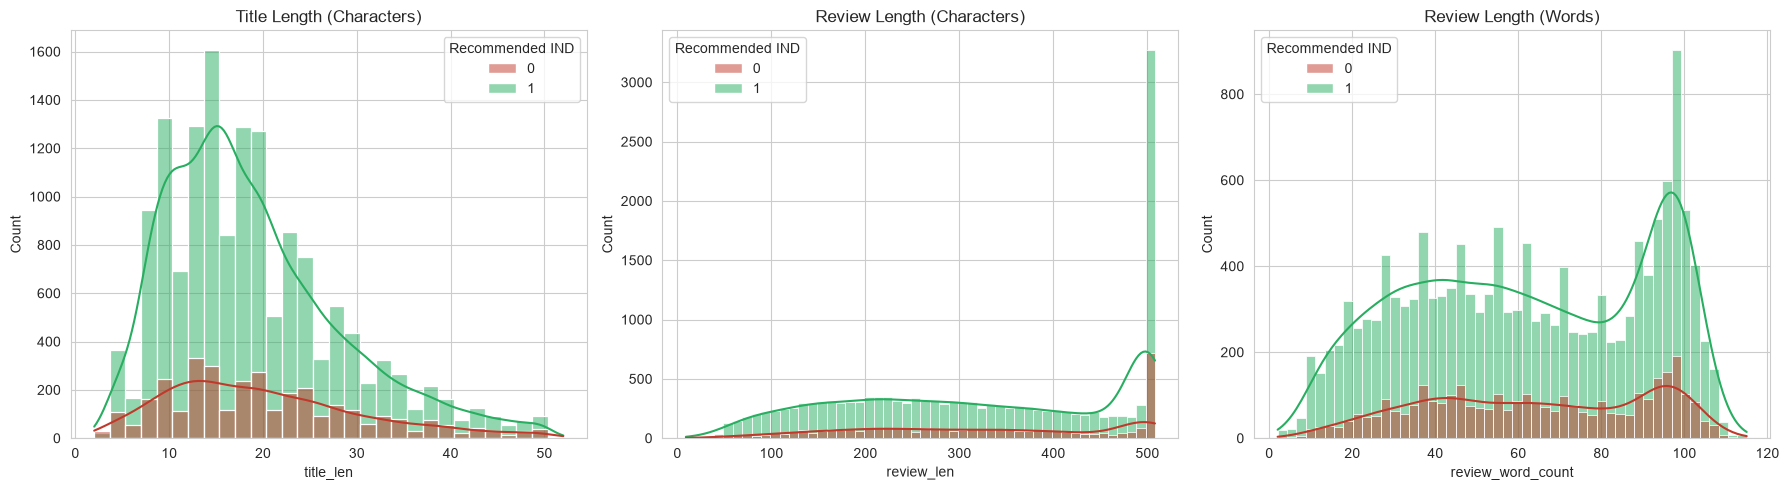

In [14]:
df['title_len'] = df['Title'].astype(str).apply(len)
df['review_len'] = df['Review Text'].astype(str).apply(len)
df['review_word_count'] = df['Review Text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Title Length
sns.histplot(data=df, x='title_len', hue='Recommended IND', ax=axes[0],
             palette=['#c0392b', '#27ae60'], bins=30, kde=True)
axes[0].set_title('Title Length (Characters)')

# Review Length
sns.histplot(data=df, x='review_len', hue='Recommended IND', ax=axes[1],
             palette=['#c0392b', '#27ae60'], bins=50, kde=True)
axes[1].set_title('Review Length (Characters)')

# Word Count
sns.histplot(data=df, x='review_word_count', hue='Recommended IND', ax=axes[2],
             palette=['#c0392b', '#27ae60'], bins=50, kde=True)
axes[2].set_title('Review Length (Words)')

plt.tight_layout()
plt.show()



In [15]:
print(df[['title_len', 'review_len', 'review_word_count']].describe().round(1))

       title_len  review_len  review_word_count
count    18442.0     18442.0            18442.0
mean        19.1       320.0               62.4
std          9.6       142.0               28.1
min          2.0         9.0                2.0
25%         12.0       201.0               39.0
50%         17.0       317.5               62.0
75%         24.0       478.0               90.0
max         52.0       508.0              115.0


### Age group vs. recommendation

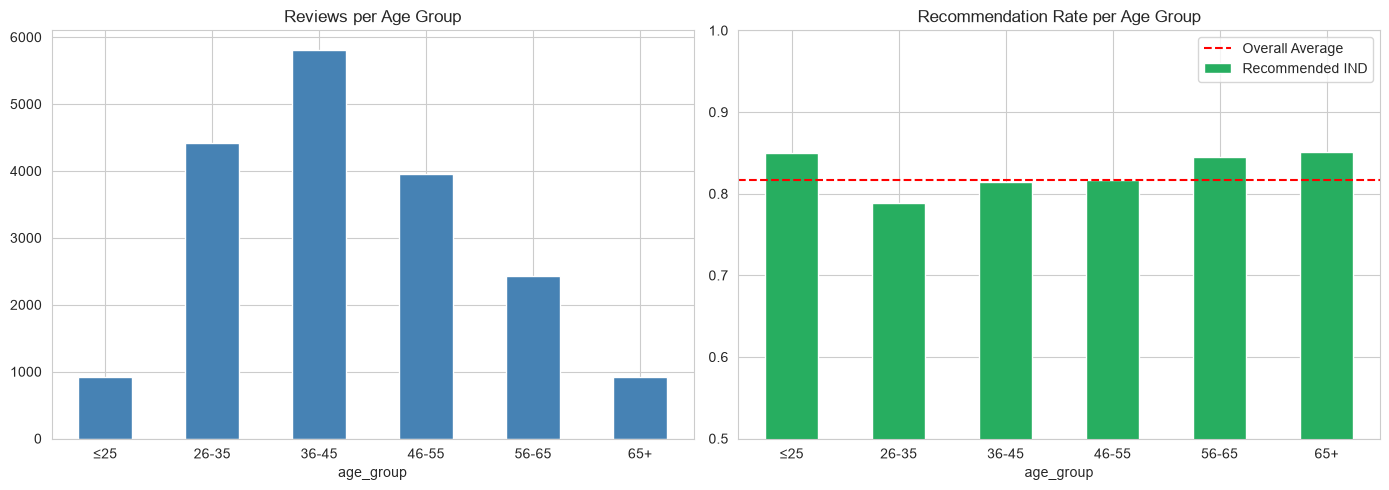

In [16]:
df['age_group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['≤25', '26-35', '36-45', '46-55', '56-65', '65+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of reviews per age group
df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Reviews per Age Group')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Recommendation rate per age group
df.groupby('age_group')['Recommended IND'].mean().plot(kind='bar', ax=axes[1], color='#27ae60')
axes[1].set_title('Recommendation Rate per Age Group')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axhline(df['Recommended IND'].mean(), color='red', linestyle='--', label='Overall Average')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()

### Top Clothing IDs (most recommended products)

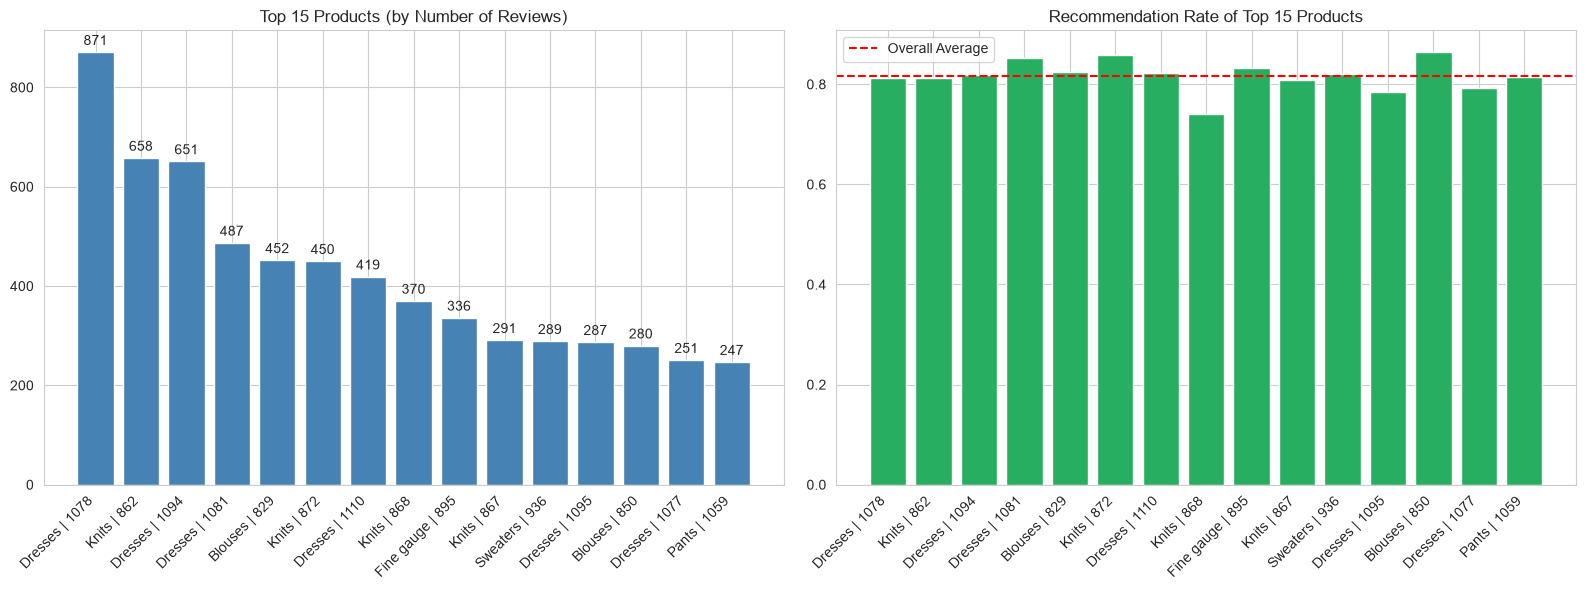

In [17]:
# Create a readable label from available columns
id_labels = (
    df.groupby('Clothing ID')[['Division Name', 'Department Name', 'Class Name']]
    .first()
)

id_labels['label'] = (
    id_labels['Class Name'] + ' | '
    + id_labels.index.astype(str)
)


# Top 15 products
top_products = df['Clothing ID'].value_counts().head(15)
top_ids = top_products.index
labels = [id_labels.loc[cid, 'label'] for cid in top_ids]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Review count
axes[0].bar(range(len(top_ids)), top_products.values, color='steelblue')
axes[0].set_title('Top 15 Products (by Number of Reviews)')
axes[0].set_xticks(range(len(top_ids)))
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].bar_label(axes[0].containers[0], padding=3)

# Recommendation rate
rec_rates = df[df['Clothing ID'].isin(top_ids)].groupby('Clothing ID')['Recommended IND'].mean()
axes[1].bar(range(len(top_ids)), [rec_rates[cid] for cid in top_ids], color='#27ae60')
axes[1].axhline(df['Recommended IND'].mean(), color='red', linestyle='--', label='Overall Average')
axes[1].set_title('Recommendation Rate of Top 15 Products')
axes[1].set_xticks(range(len(top_ids)))
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

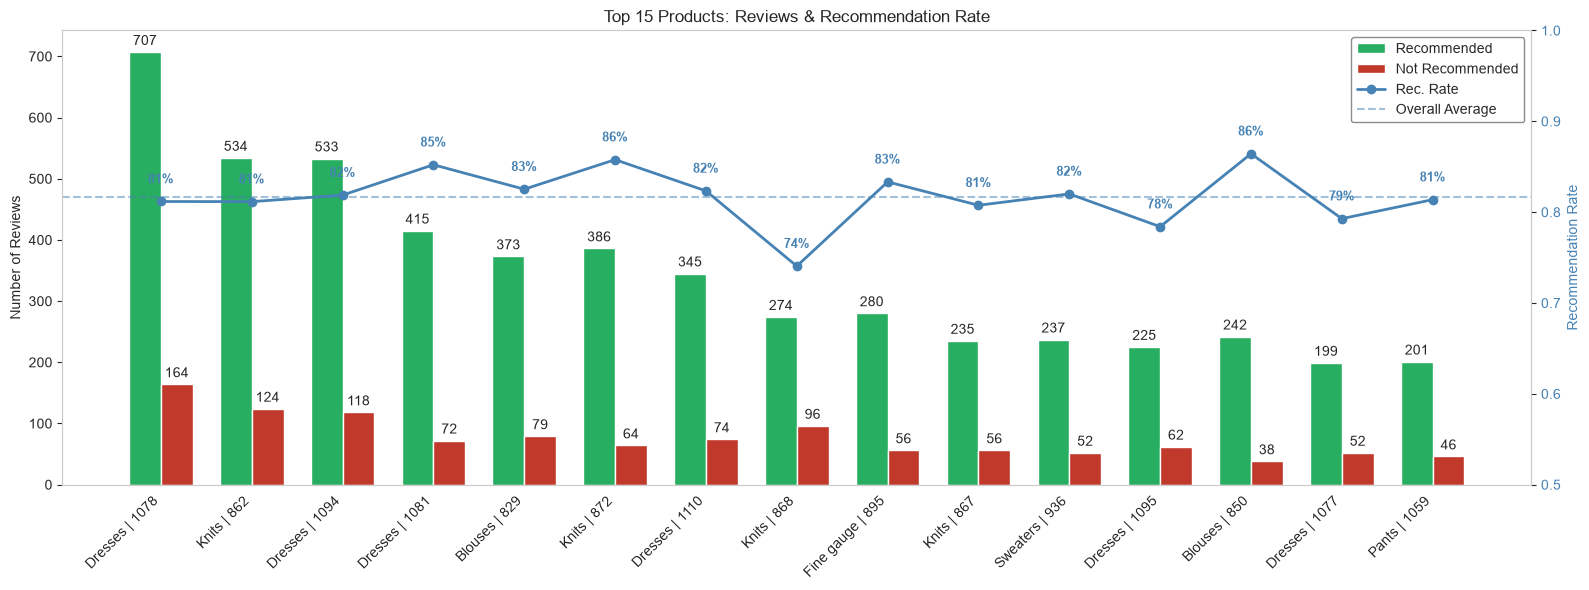

In [18]:
# Create labels
id_labels = (
    df.groupby('Clothing ID')[['Division Name', 'Department Name', 'Class Name']]
    .first()
)
id_labels['label'] = id_labels['Class Name'] + ' | ' + id_labels.index.astype(str)

# Top 15 products
top_ids = df['Clothing ID'].value_counts().head(15).index
labels = [id_labels.loc[cid, 'label'] for cid in top_ids]

# Count recommended vs not recommended per product
counts = (
    df[df['Clothing ID'].isin(top_ids)]
    .groupby(['Clothing ID', 'Recommended IND'])
    .size()
    .unstack(fill_value=0)
)
counts = counts.loc[top_ids]

# Recommendation rate per product
rec_rate = counts[1] / (counts[0] + counts[1])

fig, ax1 = plt.subplots(figsize=(16, 6))

x = np.arange(len(top_ids))
width = 0.35

# Bars
bar_rec = ax1.bar(x - width/2, counts[1], width, color='#27ae60', label='Recommended')
bar_not = ax1.bar(x + width/2, counts[0], width, color='#c0392b', label='Not Recommended')
ax1.bar_label(bar_rec, padding=3)
ax1.bar_label(bar_not, padding=3)
ax1.set_ylabel('Number of Reviews')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.grid(False)

# Recommendation rate on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x, rec_rate.values, color='steelblue', marker='o', linewidth=2, label='Rec. Rate', zorder=5)
ax2.axhline(df['Recommended IND'].mean(), color='steelblue', linestyle='--', alpha=0.5, label='Overall Average')
ax2.set_ylabel('Recommendation Rate', color='steelblue')
ax2.set_ylim(0.5, 1.0)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.grid(False)

# Percentage labels on the line
for i, val in enumerate(rec_rate.values):
    ax2.text(i, val + 0.02, f'{val:.0%}', ha='center', fontsize=9,
             color='steelblue', fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
           framealpha=0.9, edgecolor='gray')

ax1.set_title('Top 15 Products: Reviews & Recommendation Rate')

plt.tight_layout()
plt.show()

### Key Findings

In [19]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"  Dataset:              {df.shape[0]:,} Reviews, {df.shape[1]} Columns")
print(f"  Missing Values:       {df.isnull().sum().sum()}")
print(f"  Unique Products:      {df['Clothing ID'].nunique()}")
print(f"  Target Balance:       {df['Recommended IND'].mean():.1%} recommended")
print(f"  Age Range:            {df['Age'].min()} - {df['Age'].max()} (Median: {df['Age'].median():.0f})")
print(f"  Ø Review Length:      {df['Review Text'].astype(str).apply(lambda x: len(x.split())).mean():.0f} Words")
print(f"  Ø Positive Feedback:  {df['Positive Feedback Count'].mean():.1f}")
print("=" * 60)

EDA SUMMARY
  Dataset:              18,442 Reviews, 13 Columns
  Missing Values:       0
  Unique Products:      531
  Target Balance:       81.6% recommended
  Age Range:            18 - 99 (Median: 41)
  Ø Review Length:      62 Words
  Ø Positive Feedback:  2.7


### WordCloud (Review Text)

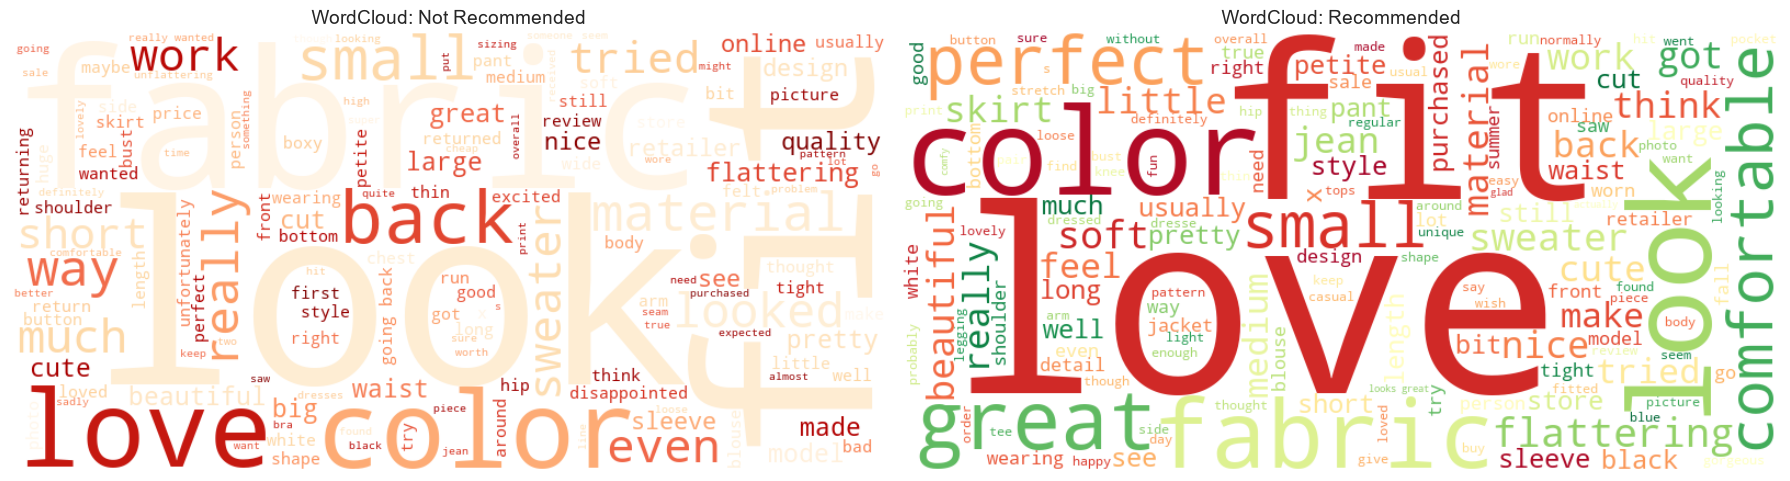

In [20]:
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)
stopwords.update(['dress', 'top', 'shirt', 'size', 'wear', 'will', 'one', 'ordered', 'bought'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (label, val) in enumerate([(0, 'Not Recommended'), (1, 'Recommended')]):
    text = ' '.join(df[df['Recommended IND'] == label]['Review Text'].astype(str))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=150,
        colormap='RdYlGn' if label == 1 else 'OrRd',
        random_state=42
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'WordCloud: {val}', fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### WordCloud (Title)

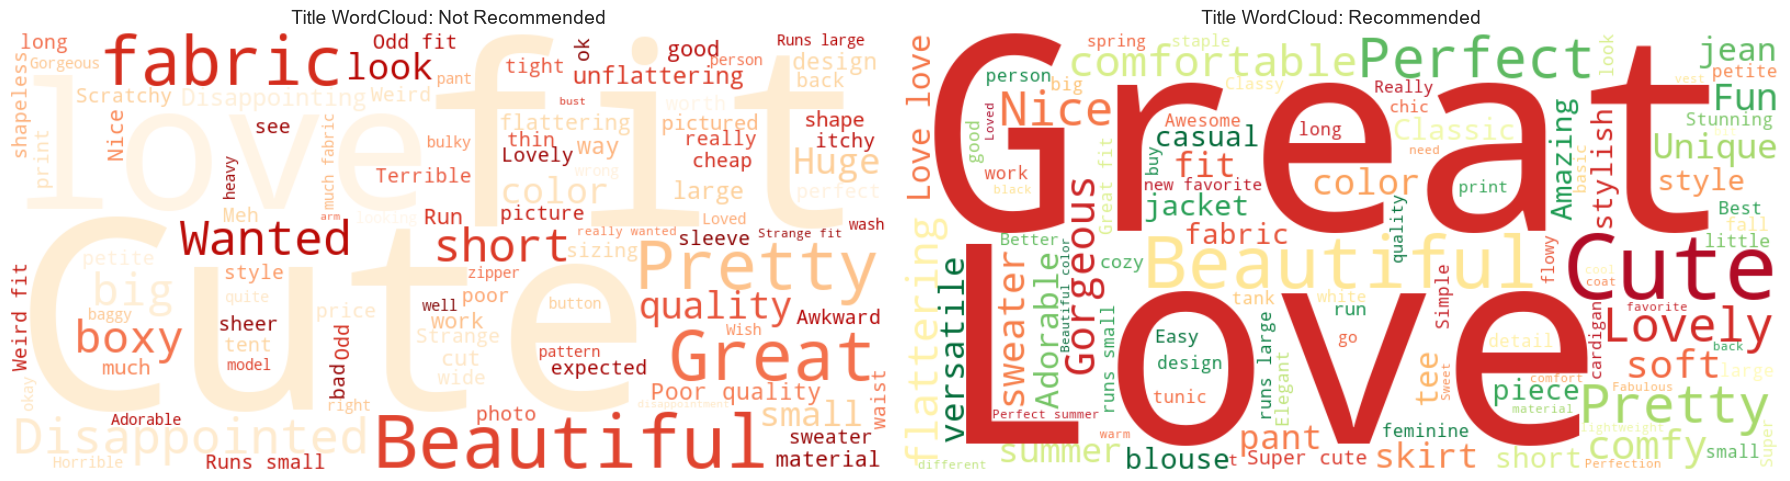

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (label, val) in enumerate([(0, 'Not Recommended'), (1, 'Recommended')]):
    text = ' '.join(df[df['Recommended IND'] == label]['Title'].astype(str))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='RdYlGn' if label == 1 else 'OrRd',
        random_state=42
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Title WordCloud: {val}', fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Top Unigrams (single words)

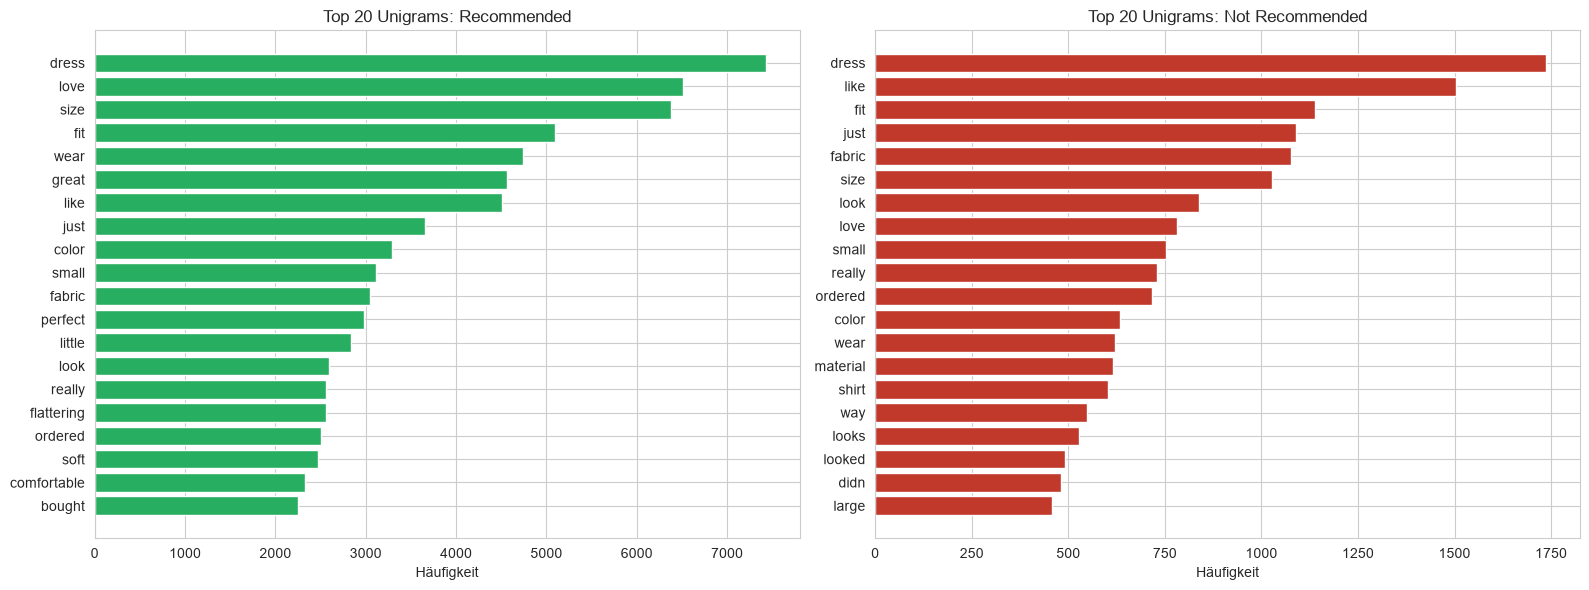

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n_gram_range=(1, 1), top_n=15):
    vec = CountVectorizer(
        ngram_range=n_gram_range,
        stop_words='english',
        max_features=5000
    ).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, val, color) in enumerate([
    (1, 'Recommended', '#27ae60'),
    (0, 'Not Recommended', '#c0392b')    
]):
    corpus = df[df['Recommended IND'] == label]['Review Text'].astype(str).tolist()
    top = get_top_ngrams(corpus, n_gram_range=(1, 1), top_n=20)
    words, counts = zip(*top)
    axes[i].barh(range(len(words)), counts, color=color)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 20 Unigrams: {val}')
    axes[i].set_xlabel('Häufigkeit')

plt.tight_layout()
plt.show()

### Top Bigrams (word couples)

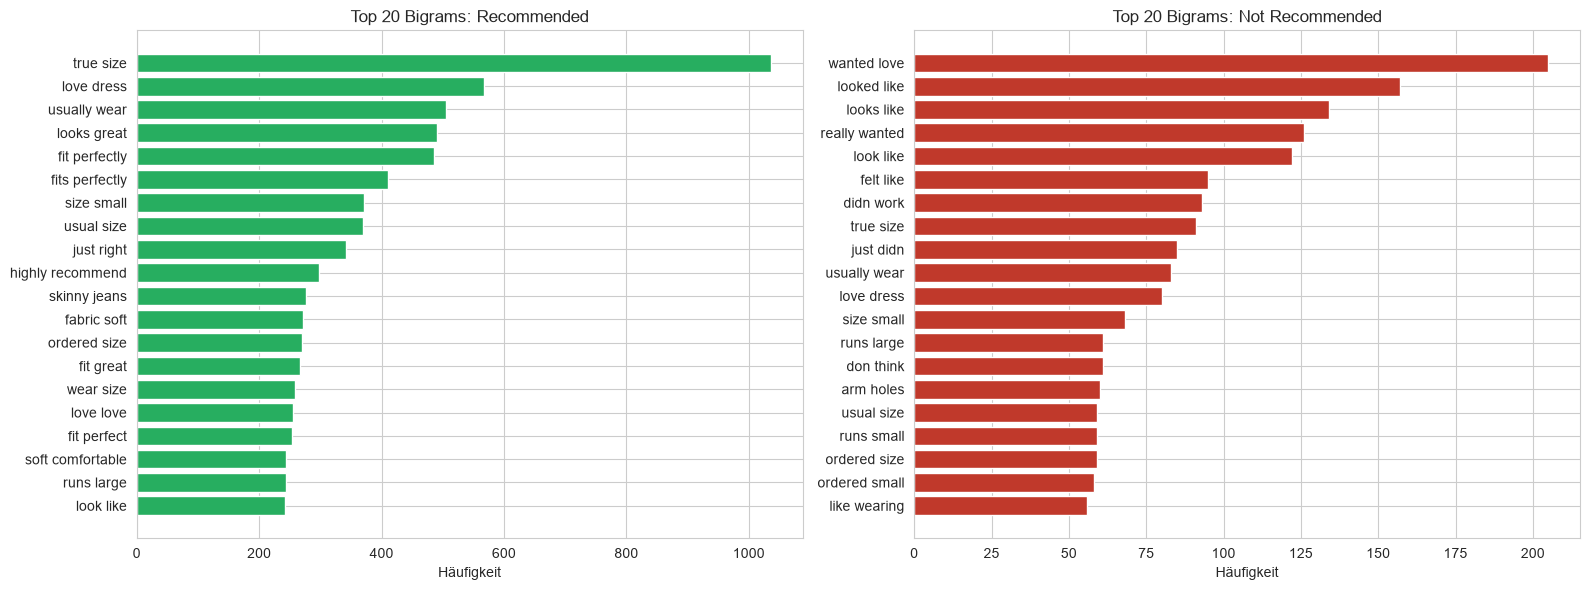

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, val, color) in enumerate([
    (1, 'Recommended', '#27ae60'),
    (0, 'Not Recommended', '#c0392b')    
]):
    corpus = df[df['Recommended IND'] == label]['Review Text'].astype(str).tolist()
    top = get_top_ngrams(corpus, n_gram_range=(2, 2), top_n=20)
    words, counts = zip(*top)
    axes[i].barh(range(len(words)), counts, color=color)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 20 Bigrams: {val}')
    axes[i].set_xlabel('Häufigkeit')

plt.tight_layout()
plt.show()

### Top Trigrams (group of 3)

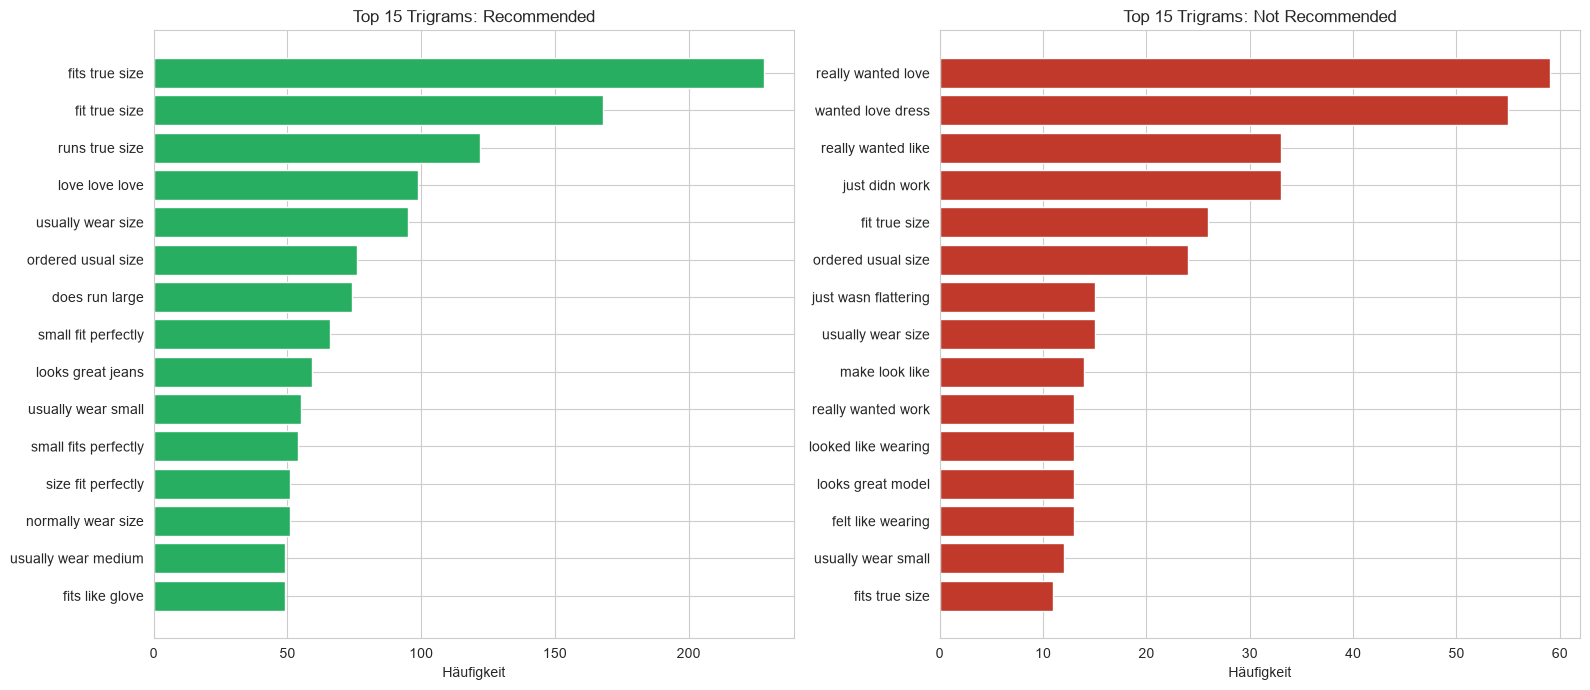

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, (label, val, color) in enumerate([
    (1, 'Recommended', '#27ae60'),
    (0, 'Not Recommended', '#c0392b')
    
]):
    corpus = df[df['Recommended IND'] == label]['Review Text'].astype(str).tolist()
    top = get_top_ngrams(corpus, n_gram_range=(3, 3), top_n=15)
    words, counts = zip(*top)
    axes[i].barh(range(len(words)), counts, color=color)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 15 Trigrams: {val}')
    axes[i].set_xlabel('Häufigkeit')

plt.tight_layout()
plt.show()

### Text-Insights Summary

In [25]:
print("=" * 60)
print("TEXT ANALYSIS SUMMARY")
print("=" * 60)

for label, val in [(0, 'Not Recommended'), (1, 'Recommended')]:
    subset = df[df['Recommended IND'] == label]['Review Text'].astype(str)
    word_counts = subset.apply(lambda x: len(x.split()))
    print(f"\n  {val}:")
    print(f"    Review count:           {len(subset)}")
    print(f"    Avg words per review:   {word_counts.mean():.1f}")
    print(f"    Median words:           {word_counts.median():.0f}")
    print(f"    Max words:              {word_counts.max()}")

print("\n" + "=" * 60)

TEXT ANALYSIS SUMMARY

  Not Recommended:
    Review count:           3389
    Avg words per review:   63.8
    Median words:           64
    Max words:              111

  Recommended:
    Review count:           15053
    Avg words per review:   62.1
    Median words:           62
    Max words:              115



## Building Pipeline

## Training Pipeline

## Fine-Tuning Pipeline